# Homework 4

Name: John "Jack" Mayberry

EID: jmm23398


Name: Lily Nguyen

EID: lmn034

## Linear Regression with Gradient Descent

Your task in this assignment is to implement Multiple Linear Regression. 

We will use the New York City Taxi trip reports in the Year 2013. 
The dataset was released under the FOIL (The Freedom of Information Law) and made public by Chris Whong (\url{https://chriswhong.com/open-data/foil_nyc_taxi/}).



# Taxi Data Set
The data set itself is a simple text file. Each taxi trip report is a different line in the file. Among other things, each trip report 
includes the starting point, the drop-off point, corresponding timestamps, and information related to the payment. The data are reported 
by the time that the trip ended, i.e., upon arriving in the order of the drop-off timestamps. 
The attributes present on each line of the file are, in order:



| index | **Attribute** | **Description** |
| --- | --- | --- |
| 0 | medallion           |  an md5sum of the identifier of the taxi - vehicle bound (Taxi ID)  | 
| 1 | hack license       |  an md5sum of the identifier for the taxi license (Driver ID)  |  
| 2 | pickup datetime    | time when the passenger(s) were picked up  |  
| 3 | dropoff datetime   | time when the passenger(s) were dropped off  | 
| 4 | trip time in secs | duration of the trip  |  
| 5 | trip distance | trip distance in miles  |  
| 6 | pickup longitude | longitude coordinate of the pickup location  |  
| 7 | pickup latitude | latitude coordinate of the pickup location  |  
| 8 | dropoff longitude | longitude coordinate of the drop-off location   |  
| 9 | dropoff latitude | latitude coordinate of the drop-off location  | 
| 10 | payment type | the payment method -credit card or cash  |  
| 11 | fare amount | fare amount in dollars  |  
| 12 | surcharge | surcharge in dollars  |  
| 13 | mta tax | tax in dollars  |  
| 14 | tip amount | tip in dollars  |  
| 15 | tolls amount | bridge and tunnel tolls in dollars  |  
| 16 | total amount | total paid amount in dollars  |  




The data files are in comma separated values (CSV) format. Example lines from the file are:

07290D3599E7A0D62097A346EFCC1FB5,E7750A37CAB07D0DFF0AF7E3573AC141,\\
2013-01-01,00:00:00,2013-01-01 00:02:00,120,0.44,-73.956528,40.716976,-73.962440,\\
40.715008,CSH,3.50,0.50,0.50,0.00,0.00,4.50

22D70BF00EEB0ADC83BA8177BB861991,3FF2709163DE7036FCAA4E5A3324E4BF,\\
2013-01-01,00:02:00,2013-01-01 00:02:00,0,0.00,0.000000,0.000000,0.000000,0.000000,\\
CSH,27.00,0.00,0.50,0.00,0.00,27.50

0EC22AAF491A8BD91F279350C2B010FD,778C92B26AE78A9EBDF96B49C67E4007,\\
2013-01-01,00:01:00,2013-01-01 00:03:00,120,0.71,-73.973145,40.752827,-73.965897\\
73.965897,40.760445,CSH,4.00,0.50,0.50,0.00,0.00,5.00



In [382]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

In [383]:
df = pd.read_csv('nyc-taxi-data.csv.bz2')
df

,07290D3599E7A0D62097A346EFCC1FB5,E7750A37CAB07D0DFF0AF7E3573AC141,2013-01-01 00:00:00,2013-01-01 00:02:00,120,0.44,-73.956528,40.716976,-73.962440,40.715008,CSH,3.50,0.50,0.50.1,0.00,0.00.1,4.50
0,22D70BF00EEB0ADC83BA8177BB861991,3FF2709163DE7036FCAA4E5A3324E4BF,2013-01-01 00:02:00,2013-01-01 00:02:00,0,0.00,0.000000,0.000000,0.000000,0.000000,CSH,27.0,0.0,0.5,0.00,0.0,27.50
1,0EC22AAF491A8BD91F279350C2B010FD,778C92B26AE78A9EBDF96B49C67E4007,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.71,-73.973145,40.752827,-73.965897,40.760445,CSH,4.0,0.5,0.5,0.00,0.0,5.00
2,1390FB380189DF6BBFDA4DC847CAD14F,BE317B986700F63C43438482792C8654,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.48,-74.004173,40.720947,-74.003838,40.726189,CSH,4.0,0.5,0.5,0.00,0.0,5.00
3,3B4129883A1D05BE89F2C929DE136281,7077F9FD5AD649AEACA4746B2537E3FA,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.61,-73.987373,40.724861,-73.983772,40.730995,CRD,4.0,0.5,0.5,0.00,0.0,5.00
4,5FAA7F69213D26A42FA435CA9511A4FF,00B7691D86D96AEBD21DD9E138F90840,2013-01-01 00:02:00,2013-01-01 00:03:00,60,0.00,0.000000,0.000000,0.000000,0.000000,CRD,2.5,0.5,0.5,0.25,0.0,3.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,A0AFE6B722F15B7A0FDFEEA954BE316A,93D505C96BD248DC390FD47F747D762D,2013-01-01 03:44:00,2013-01-01 03:46:00,120,0.79,-73.963593,40.710941,-74.027779,40.629894,CSH,4.5,0.5,0.5,0.00,0.0,5.50
49995,A0DEAEC3D5592AE94B876356F12F8158,6A35995FBD5399AB131B89623C344782,2013-01-01 03:35:00,2013-01-01 03:46:00,660,2.41,-73.955833,40.768272,-73.987724,40.775490,CRD,10.0,0.5,0.5,2.10,0.0,13.10
49996,A154EFA0695A29423B078C7F5D5B2CB5,F38E7C3381F28C9B3E51C0B6DDBDF68A,2013-01-01 03:40:00,2013-01-01 03:46:00,360,1.63,-73.963951,40.709934,-73.949364,40.695381,CRD,7.0,0.5,0.5,2.25,0.0,10.25
49997,A2B97CECFEA4C8DE45D8FC251E80AF1D,68AE01DDBDEDDFF772905561744A1072,2013-01-01 03:34:00,2013-01-01 03:46:00,720,4.04,-73.952759,40.776524,-73.983093,40.738796,CRD,14.5,0.5,0.5,3.00,0.0,18.50


## Task - 1
The dataset is a real-world dataset and many records are incorrect and wrong. Your task is first to describe at least 4 data clean up tasks and implement them on this data set.

For example, you can define to remove lines with the following property, if a taxi trip (one of the data rows) has a travel distance less than 1 mile and total amount of more than 20 dollar, then it is an wrong record. 

Another example is that you would expect to have a float number (e.g., index 12 to 16) and then you got a String in that position. You can remove such lines from your data. 

Perform the following cleanup tasks:
1. Add column headers based on the description above (no need to describe).
2. Drop rows with a travel distance < 1 mile and a total fare > $20 (no need to describe). Both conditions need to be met.
3. Your own task (please describe your task in a comment/cell).
4. Your own task (please describe your task in a comment/cell).

**(4 points)**

In [384]:
# Task 1.1

headers = ["medallion", "hack license", "pickup datetime", "dropoff datetime", "trip time in secs", "trip distance", "pickup longitude", "pickup latitude", "dropoff longitude", "dropoff latitude", "payment type", "fare amount", "surcharge", "mta tax", "tip amount", "tolls amount", "total amount"]

df.columns = headers
df.head(2)

,medallion,hack license,pickup datetime,dropoff datetime,trip time in secs,trip distance,pickup longitude,pickup latitude,dropoff longitude,dropoff latitude,payment type,fare amount,surcharge,mta tax,tip amount,tolls amount,total amount
0,22D70BF00EEB0ADC83BA8177BB861991,3FF2709163DE7036FCAA4E5A3324E4BF,2013-01-01 00:02:00,2013-01-01 00:02:00,0,0.00,0.000000,0.000000,0.000000,0.000000,CSH,27.0,0.0,0.5,0.0,0.0,27.5
1,0EC22AAF491A8BD91F279350C2B010FD,778C92B26AE78A9EBDF96B49C67E4007,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.71,-73.973145,40.752827,-73.965897,40.760445,CSH,4.0,0.5,0.5,0.0,0.0,5.0


In [385]:
# Task 1.2

print(df.shape)

df.drop(df[(df["trip distance"] < 1) & (df["total amount"] > 20)].index, inplace = True)
df.reset_index(drop = True, inplace = True)
df.shape

(49999, 17)


(49688, 17)

In [386]:
# Task 1.3

# Remove rows where the Total Amount does not equal the sum of Fare Amount, 
# Surcharge, MTA Tax, Tip Amount, and Tolls Amount. These rows likely have
# incorrect or corrupted data.

print(df.shape)

df["test total"] = df[["fare amount", "surcharge", "mta tax", "tip amount", "tolls amount"]].sum(axis=1)
df = df[df["test total"] == df["total amount"]].copy()
df.reset_index(drop = True, inplace = True)

print(df.shape)

df.drop(columns = "test total", inplace = True)

(49688, 17)
(49042, 18)


In [387]:
# Task 1.4

# Remove the rows where the payment type is 'UNK' (unknown) because these entries 
# lack information about how the trip was paid

print(df.shape)

print(df["payment type"].value_counts())
df = df[df["payment type"] != "UNK"]

df.shape

(49042, 17)
payment type
CSH    28811
CRD    20212
UNK       19
Name: count, dtype: int64


(49023, 17)

The original dataset includes 49999 lines of data. After data cleaning processes, the resulting dataset is now 49023 lines.

## Task - 2
Use the cleaned dataset from task 1.
Find out the correlations between trip distance, travel time and fare amount. Visualize the correlations in form of Scatterplot matrix. 
Describe the correlations between them. **(4 points)**

In [388]:
subset = df[["trip distance", "trip time in secs", "fare amount"]]
subset.corr()

,trip distance,trip time in secs,fare amount
trip distance,1.000000,0.774755,0.937724
trip time in secs,0.774755,1.000000,0.844991
fare amount,0.937724,0.844991,1.000000


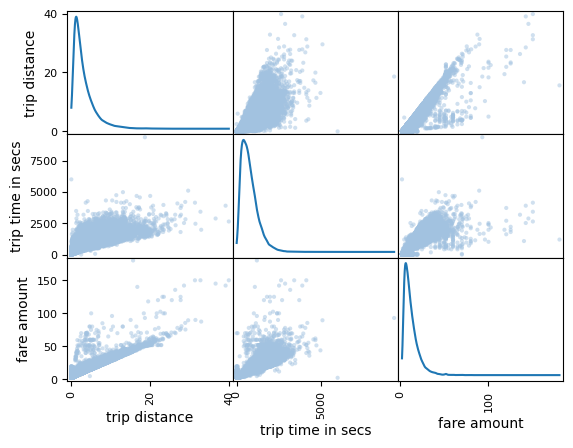

In [389]:
from pandas.plotting import scatter_matrix

scatter_matrix(subset, diagonal='kde', color='#A2C2E0')
plt.show()

Correlations:

Trip Distance vs. Trip Time in Secs: 0.774755

Correlation - Fairly Strong: Longer trips typically take longer to complete, but factors like traffic, speed limits, etc. can impact this metric.

--

Trip Time in Secs vs. Fare Amount: 0.844991

Correlation - Strong: Longer trips usually result in higher fares. Because this correlation is not stronger, distance is likely a pricing factor.

--

Trip Distance vs. Fare Amount: 0.937724

Correlation - Very Strong: Farther trips almost always result in a higher fare. Because this correlation is not stronger, time is likely a pricing factor, but not one as influential as distance.

## Task - 3
Use the cleaned dataset from task 1.
We want to find a simple line to our data (distance, money). 
We want to use trip distance, and fare amount. Use the **Scikit-learn** library to fit a line into the data. **(2 points)**

* Provide the Regression Cofficients of your model
* Write down your linear regression equation. 
* Use your model to predict the fare amount for a 3 miles trip. 

A visualization of the model is not required, but it would be nice to have and good practice.

In [390]:
subset = df[["trip distance", "fare amount"]].copy()
subset.rename(columns = {"trip distance": "distance", "fare amount": "fare"}, inplace = True)
subset.corr()

,distance,fare
distance,1.000000,0.937724
fare,0.937724,1.000000


In [391]:
from sklearn.linear_model import LinearRegression

distance = subset["distance"]
fare = subset["fare"]

my_X = np.vstack((distance, )).T
print(my_X)

[[0.71]
 [0.48]
 [0.61]
 ...
 [1.63]
 [4.04]
 [2.11]]


In [392]:
reg = LinearRegression().fit(my_X, fare)

print('Regression coefficient:', reg.coef_[0])
print('Regression intercept:', reg.intercept_)

Regression coefficient: 2.864843503355487
Regression intercept: 3.7418896114652753


Regression Equation:

$y = 2.86x + 3.74$

In [393]:
reg.predict(my_X)

array([ 5.7759285 ,  5.11701449,  5.48944415, ...,  8.41158452,
       15.31585737,  9.7867094 ], shape=(49023,))

In [394]:
# Predict fare for 3 mile trip
prediction = reg.predict([[3]])

print(f'The predicted fare for a 3 mile trip is ${prediction[0]:.2f}.')

The predicted fare for a 3 mile trip is $12.34.


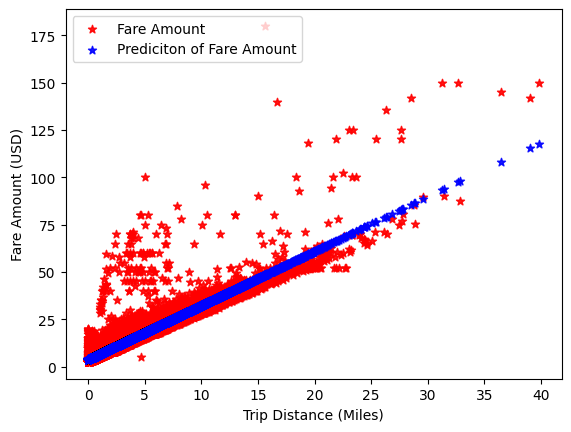

In [395]:
# Scatterplot and linear regression visualization
fig = plt.figure()
plt.scatter(distance, fare, c="red", alpha=0.9, marker='*',label="Fare Amount")
plt.scatter(distance, reg.predict(my_X), c="blue", alpha=0.9, marker='*',label="Prediciton of Fare Amount")

plt.xlabel("Trip Distance (Miles)")
plt.ylabel("Fare Amount (USD)")
plt.legend(loc='upper left')
plt.show()

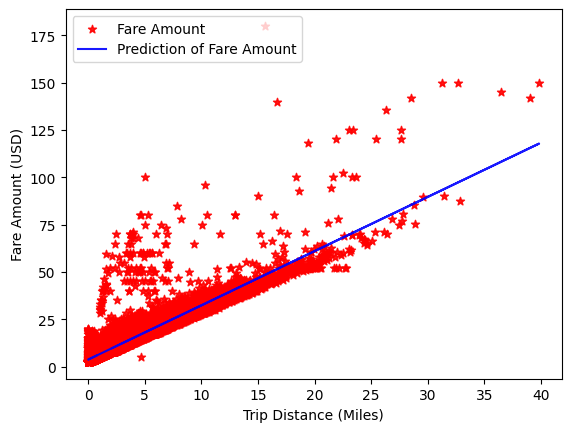

In [396]:
fig = plt.figure()
plt.scatter(distance, fare, c="red", alpha=0.9, marker='*',label="Fare Amount")
plt.plot(distance, reg.predict(my_X), c="blue", alpha=0.9,label="Prediction of Fare Amount")

plt.xlabel("Trip Distance (Miles)")
plt.ylabel("Fare Amount (USD)")
plt.legend(loc='upper left')
plt.show()

## Task - 4
Fit a Multiple Linear Regression hyperplane into this data. We are interested to predict total amount out of trip distance, tavel time. **(4 points)**
Use the **Scikit-learn** library.

* Provide the Regression Cofficients of your model
* Write down your Multiple Linear Regression equation. 
* Use your model to predict the total amount for a 3 miles trip and 6 min travel time. 

A visualization of the model is not required, but it would be nice to have and good practice.

In [397]:
distance = df['trip distance']
time = df['trip time in secs']
total = df['total amount']

x_vals = np.vstack((distance, time, )).T
reg = LinearRegression().fit(x_vals, total)

print('Regression Coefficient (distance):', reg.coef_[0])
print('Regression Coefficient (time):', reg.coef_[1])
print('Intercept:', reg.intercept_)

Regression Coefficient (distance): 2.4409397753457664
Regression Coefficient (time): 0.0053843454191559404
Intercept: 3.1368401526241705


The Multiple Linear Regresion equation is

$y=3.14+2.44x_1+0.01x_2$

In [398]:
# predict total amount of time for 3 miles trip and 6 minute travel time
prediction = reg.predict([[3, 360]])
print(f'The predicted total amount for a 3 mile trip and 6 minute travel time is ${prediction[0]:.2f}.')

The predicted total amount for a 3 mile trip and 6 minute travel time is $12.40.


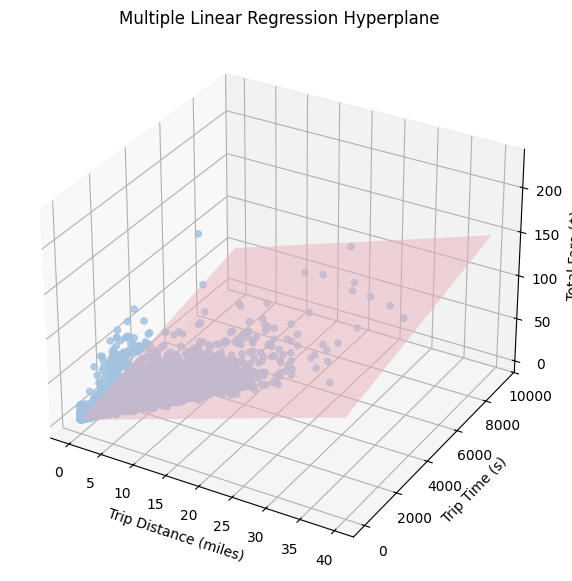

In [399]:
# MLR hyperplane visualization
distance = df['trip distance'].values
time = df['trip time in secs'].values
total_amount = df['total amount'].values

distance_range = np.linspace(distance.min(), distance.max(), 50)
time_range = np.linspace(time.min(), time.max(), 50)

# design matrix X
ones = np.ones(len(distance))
X = np.column_stack([ones, distance, time])

# least squares beta
XT_X = X.T @ X
XT_y = X.T @ total_amount.reshape(-1, 1)
beta = np.linalg.inv(XT_X) @ XT_y # beta parameters

# objective function f
def f(distance, time, beta):
    return beta[0] + beta[1] * distance + beta[2] * time

# meshgrid for plotting
dist_grid, time_grid = np.meshgrid(distance_range, time_range)
y_hat = f(dist_grid, time_grid, beta)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(distance, time, total_amount, color='#A2C2E0', alpha=0.8)
ax.plot_surface(dist_grid, time_grid, y_hat, color='pink', alpha=0.5) # plot plane
ax.set_xlabel('Trip Distance (miles)')
ax.set_ylabel('Trip Time (s)')
ax.set_zlabel('Total Fare ($)')
ax.set_title('Multiple Linear Regression Hyperplane')
plt.show()

## Task - 5 - Gradient Descent
Implement the gradient descent optimization to find the optimal parameters for our Simple Linear Regression model of task 3. **(6 points)**

* Define and set your learning rate (start with a very small number and increase it if your GC works)
* Instantiate all coefficients from zero
* Run maximum 400 interations. You can stop if your cost converge with a precision of 0.01 
* Print and visualize the optimization costs
* Provide the Regression Coefficients of your model after stop or convergance. 

Please note that a visualization **is** required, unlike in Task 3 and 4.

In [400]:
distances = df['trip distance'].values
fares = df['fare amount'].values
n = len(distances)

# instantiate all coefficients from zero
b_0 = 0
b_1 = 0

learning_rate = 0.05
precision = 0.0001
max_iters = 400

# tracking the costs
costs = []
old_cost = float('inf')

# gradient descent loop
for i in range(max_iters):

    # calculate prediction with current regression coefficients
    prediction = b_0 + b_1 * distances

    err = prediction - fares

    # mean squared error cost
    cost = (1 / n) * np.sum(err ** 2)
    costs.append(cost)

    # compute gradients
    b0_gradient = (2 / n) * np.sum(err)
    b1_gradient = (2 / n) * np.dot(distances, err)

    # update weights - regression coefficients
    b_1 = b_1 - learning_rate * b1_gradient
    b_0 = b_0 - learning_rate * b0_gradient

    print(f"Iteration {i+1}: Intercept = {b_0:.2f}, Slope = {b_1:.2f}, Cost = {cost:.2f}")

    # stop if the cost is not decreasing significantly
    if(abs(cost - old_cost) <= precision):
        print('Stopped at iteration', i)
        break

    old_cost = cost

Iteration 1: Intercept = 1.27, Slope = 6.23, Cost = 234.75
Iteration 2: Intercept = 0.47, Slope = 1.06, Cost = 162.54
Iteration 3: Intercept = 1.36, Slope = 5.27, Cost = 113.66
Iteration 4: Intercept = 0.84, Slope = 1.77, Cost = 80.55
Iteration 5: Intercept = 1.48, Slope = 4.61, Cost = 58.11
Iteration 6: Intercept = 1.16, Slope = 2.24, Cost = 42.88
Iteration 7: Intercept = 1.61, Slope = 4.15, Cost = 32.53
Iteration 8: Intercept = 1.42, Slope = 2.55, Cost = 25.48
Iteration 9: Intercept = 1.75, Slope = 3.83, Cost = 20.66
Iteration 10: Intercept = 1.65, Slope = 2.75, Cost = 17.36
Iteration 11: Intercept = 1.90, Slope = 3.61, Cost = 15.08
Iteration 12: Intercept = 1.85, Slope = 2.87, Cost = 13.51
Iteration 13: Intercept = 2.04, Slope = 3.45, Cost = 12.40
Iteration 14: Intercept = 2.02, Slope = 2.95, Cost = 11.63
Iteration 15: Intercept = 2.17, Slope = 3.34, Cost = 11.07
Iteration 16: Intercept = 2.18, Slope = 2.99, Cost = 10.67
Iteration 17: Intercept = 2.30, Slope = 3.25, Cost = 10.37
Ite

In [401]:
# get the parameters
print('Slope b_1:', b_1)
print('Intercept b_0:', b_0)
print("Final cost (aka MSE):", costs[-1])

# final cost is the average squared error of predictions after training!

Slope b_1: 2.873247824238537
Intercept b_0: 3.695556319783075
Final cost (aka MSE): 8.895975484174105


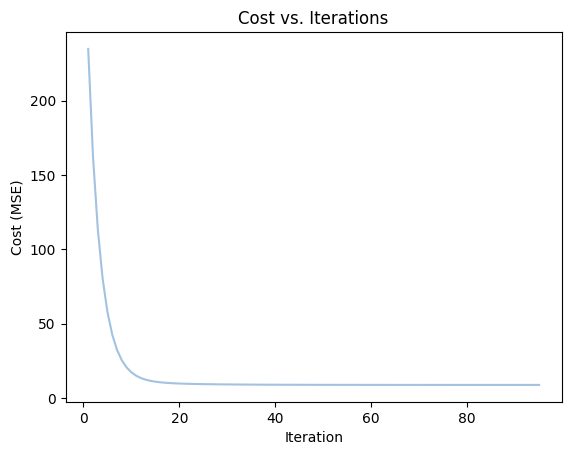

In [402]:
# visualize with plot
plt.plot(range(1, len(costs)+1), costs, color="#A2C2E0")
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Cost vs. Iterations")
plt.show()

In [403]:
print('The final Regression Coefficients are:')
print(f"Intercept (b_0): {b_0:.2f}")
print(f"Slope (b_1): {b_1:.2f}")

The final Regression Coefficients are:
Intercept (b_0): 3.70
Slope (b_1): 2.87


The fit we got from the method of gradient descent is:

$y=2.87x+3.70$

This approximation is very close to our linear regression prediction from question 3:

$y = 2.86x + 3.74$
